LOADING VAHAN VEHICLE CATEGORY DATA

Dataset Shape:
(584267, 9)

Columns:
['id', 'date', 'state_name', 'state_code', 'office_name', 'office_code', 'vehicle_type', 'category', 'registrations']

First 5 rows:
   id        date                   state_name  state_code     office_name  \
0   0  2020-04-01  Andaman And Nicobar Islands          35  Port Blair Dto   
1   1  2020-04-01  Andaman And Nicobar Islands          35  Port Blair Dto   
2   2  2020-04-01  Andaman And Nicobar Islands          35  Port Blair Dto   
3   3  2020-04-01  Andaman And Nicobar Islands          35  Port Blair Dto   
4   4  2020-04-01  Andaman And Nicobar Islands          35  Port Blair Dto   

  office_code                vehicle_type          category  registrations  
0         AN1         Heavy Goods Vehicle  Vehicle Category            8.0  
1         AN1         Light Goods Vehicle  Vehicle Category           19.0  
2         AN1         Light Motor Vehicle  Vehicle Category           12.0  
3         AN1   

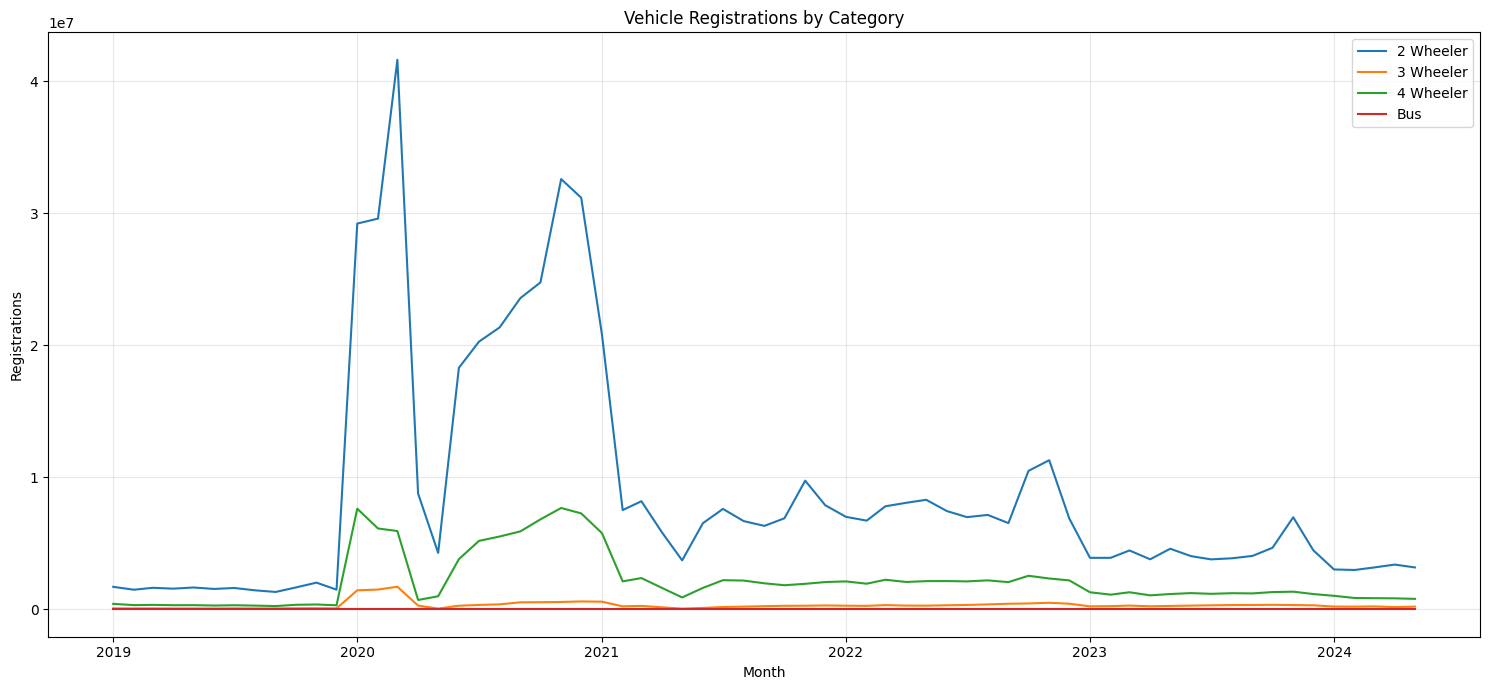

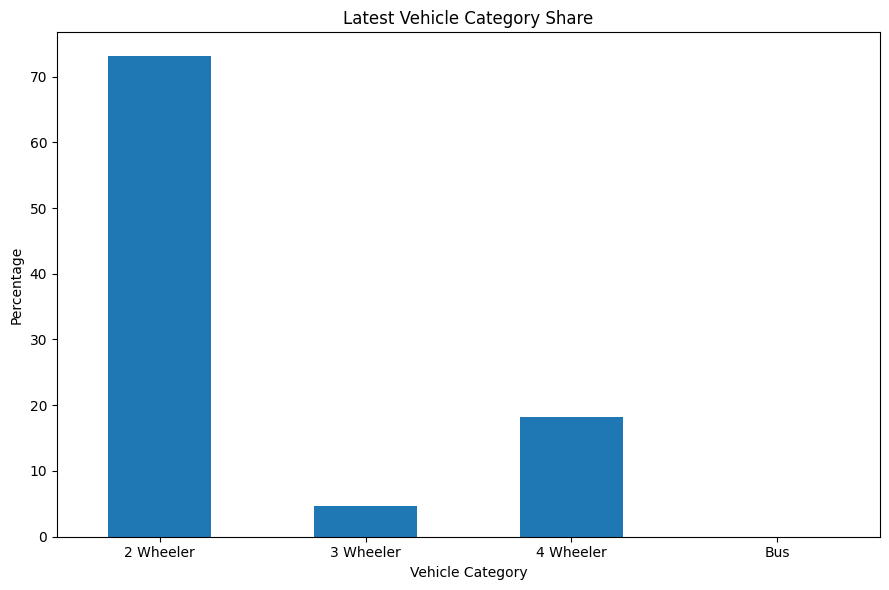


State category dataset saved.

TOP STATES
state_name
Andhra Pradesh       157960221.0
Tamil Nadu           139599930.0
Rajasthan             87937973.0
Arunachal Pradesh     83242443.0
Kerala                63250609.0
Punjab                41000076.0
Madhya Pradesh        26931559.0
Bihar                 24909621.0
West Bengal           24215553.0
Delhi                 19538600.0
Himachal Pradesh      19313888.0
Uttar Pradesh         16845359.0
Maharashtra           12123835.0
Gujarat                8106553.0
Karnataka              8041037.0
Haryana                4052344.0
Odisha                 3877383.0
Jharkhand              2982595.0
Chhattisgarh           2956949.0
Assam                  2833660.0
Name: registrations, dtype: float64

PIPELINE COMPLETED SUCCESSFULLY

Generated files:

vahan_category_output/
│
├── vahan_vehicle_category_features.csv
├── vehicle_category_trends.png
├── vehicle_category_share.png
└── state_vehicle_category.csv



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import re

# ============================================================
# 1. FILE PATH
# ============================================================

FILE_PATH = "/content/vahan-vehicle-registrations-by-vehicle-category-71m55i.csv"

OUTPUT_DIR = "vahan_category_output"

os.makedirs(OUTPUT_DIR, exist_ok=True)


# ============================================================
# 2. LOAD DATA
# ============================================================

print("=" * 60)
print("LOADING VAHAN VEHICLE CATEGORY DATA")
print("=" * 60)

df = pd.read_csv(FILE_PATH)

print("\nDataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
print(df.head())


# ============================================================
# 3. BASIC INFORMATION
# ============================================================

print("\n" + "=" * 60)
print("DATA INFORMATION")
print("=" * 60)

print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())


# ============================================================
# 4. REMOVE DUPLICATES
# ============================================================

df = df.drop_duplicates()

print("\nShape after removing duplicates:")
print(df.shape)


# ============================================================
# 5. CLEAN DATE
# ============================================================

df["date"] = pd.to_datetime(
    df["date"],
    errors="coerce"
)

df = df.dropna(
    subset=["date"]
)


# ============================================================
# 6. CLEAN REGISTRATIONS
# ============================================================

df["registrations"] = pd.to_numeric(
    df["registrations"],
    errors="coerce"
)

df = df.dropna(
    subset=["registrations"]
)


# ============================================================
# 7. CLEAN VEHICLE TYPE
# ============================================================

df["vehicle_type"] = (
    df["vehicle_type"]
    .astype(str)
    .str.strip()
)


print("\n" + "=" * 60)
print("VEHICLE TYPES")
print("=" * 60)

print(
    df["vehicle_type"]
    .value_counts()
    .to_string()
)


# ============================================================
# 8. TIME FEATURES
# ============================================================

df["year"] = df["date"].dt.year

df["month"] = df["date"].dt.month

df["quarter"] = df["date"].dt.quarter

df["year_month"] = (
    df["date"]
    .dt.to_period("M")
    .astype(str)
)


# ============================================================
# 9. VEHICLE CATEGORY GROUPING
# ============================================================

def classify_vehicle_type(vehicle):

    vehicle = str(vehicle).upper().strip()

    # -------------------------
    # 2 WHEELER
    # -------------------------

    if any(keyword in vehicle for keyword in [
        "MOTOR CYCLE",
        "MOTORCYCLE",
        "SCOOTER",
        "MOPED",
        "TWO WHEELER",
        "2 WHEELER"
    ]):
        return "2W"


    # -------------------------
    # 3 WHEELER
    # -------------------------

    elif any(keyword in vehicle for keyword in [
        "THREE WHEELER",
        "3 WHEELER",
        "AUTO RICKSHAW",
        "AUTORICKSHAW"
    ]):
        return "3W"


    # -------------------------
    # BUS
    # -------------------------

    elif "BUS" in vehicle:
        return "BUS"


    # -------------------------
    # 4 WHEELER / PASSENGER
    # -------------------------

    elif any(keyword in vehicle for keyword in [
        "MOTOR CAR",
        "LIGHT MOTOR VEHICLE",
        "LIGHT PASSENGER",
        "PASSENGER CAR",
        "CAR"
    ]):
        return "4W"


    # -------------------------
    # GOODS
    # -------------------------

    elif any(keyword in vehicle for keyword in [
        "GOODS",
        "HEAVY GOODS",
        "LIGHT GOODS"
    ]):
        return "GOODS"


    # -------------------------
    # OTHER
    # -------------------------

    else:
        return "OTHER"


df["vehicle_group"] = (
    df["vehicle_type"]
    .apply(classify_vehicle_type)
)


# ============================================================
# 10. CHECK GROUPING
# ============================================================

print("\n" + "=" * 60)
print("VEHICLE GROUP DISTRIBUTION")
print("=" * 60)

print(
    df["vehicle_group"]
    .value_counts()
)


# ============================================================
# 11. MONTHLY VEHICLE CATEGORY DATA
# ============================================================

monthly_category = (
    df.groupby(
        [
            "year_month",
            "vehicle_group"
        ]
    )["registrations"]
    .sum()
    .reset_index()
)


print("\nMonthly category data:")
print(
    monthly_category.head(20)
)


# ============================================================
# 12. PIVOT DATA
# ============================================================

category_features = (
    monthly_category
    .pivot(
        index="year_month",
        columns="vehicle_group",
        values="registrations"
    )
    .fillna(0)
    .reset_index()
)


# ============================================================
# 13. RENAME COLUMNS
# ============================================================

category_features = category_features.rename(
    columns={
        "2W": "two_wheeler",
        "3W": "three_wheeler",
        "4W": "four_wheeler",
        "BUS": "bus",
        "GOODS": "goods",
        "OTHER": "other"
    }
)


# Make sure columns exist

required_columns = [
    "two_wheeler",
    "three_wheeler",
    "four_wheeler",
    "bus",
    "goods",
    "other"
]

for col in required_columns:

    if col not in category_features.columns:

        category_features[col] = 0


# ============================================================
# 14. TOTAL REGISTRATIONS
# ============================================================

category_features["total_registrations"] = (
    category_features[required_columns]
    .sum(axis=1)
)


# ============================================================
# 15. DATE FEATURES
# ============================================================

category_features["year_month"] = pd.to_datetime(
    category_features["year_month"]
)

category_features["year"] = (
    category_features["year_month"]
    .dt.year
)

category_features["month"] = (
    category_features["year_month"]
    .dt.month
)

category_features["quarter"] = (
    category_features["year_month"]
    .dt.quarter
)


# ============================================================
# 16. CATEGORY SHARE
# ============================================================

category_features["two_wheeler_share"] = (
    category_features["two_wheeler"]
    /
    category_features["total_registrations"]
    * 100
)

category_features["three_wheeler_share"] = (
    category_features["three_wheeler"]
    /
    category_features["total_registrations"]
    * 100
)

category_features["four_wheeler_share"] = (
    category_features["four_wheeler"]
    /
    category_features["total_registrations"]
    * 100
)

category_features["bus_share"] = (
    category_features["bus"]
    /
    category_features["total_registrations"]
    * 100
)


# ============================================================
# 17. MONTHLY GROWTH
# ============================================================

category_features["total_growth"] = (
    category_features["total_registrations"]
    .pct_change()
    * 100
)


category_features["two_wheeler_growth"] = (
    category_features["two_wheeler"]
    .pct_change()
    * 100
)


category_features["three_wheeler_growth"] = (
    category_features["three_wheeler"]
    .pct_change()
    * 100
)


category_features["four_wheeler_growth"] = (
    category_features["four_wheeler"]
    .pct_change()
    * 100
)


# ============================================================
# 18. LAG FEATURES
# ============================================================

category_features["lag_1"] = (
    category_features["total_registrations"]
    .shift(1)
)

category_features["lag_3"] = (
    category_features["total_registrations"]
    .shift(3)
)

category_features["lag_6"] = (
    category_features["total_registrations"]
    .shift(6)
)

category_features["lag_12"] = (
    category_features["total_registrations"]
    .shift(12)
)


# ============================================================
# 19. CATEGORY-SPECIFIC LAGS
# ============================================================

category_features["two_wheeler_lag_1"] = (
    category_features["two_wheeler"]
    .shift(1)
)

category_features["three_wheeler_lag_1"] = (
    category_features["three_wheeler"]
    .shift(1)
)

category_features["four_wheeler_lag_1"] = (
    category_features["four_wheeler"]
    .shift(1)
)


# ============================================================
# 20. ROLLING FEATURES
# ============================================================

category_features["rolling_mean_3"] = (
    category_features["total_registrations"]
    .shift(1)
    .rolling(3)
    .mean()
)

category_features["rolling_mean_6"] = (
    category_features["total_registrations"]
    .shift(1)
    .rolling(6)
    .mean()
)

category_features["rolling_mean_12"] = (
    category_features["total_registrations"]
    .shift(1)
    .rolling(12)
    .mean()
)


# ============================================================
# 21. SAVE FINAL DATASET
# ============================================================

output_file = (
    f"{OUTPUT_DIR}/"
    "vahan_vehicle_category_features.csv"
)

category_features.to_csv(
    output_file,
    index=False
)


print("\n" + "=" * 60)
print("PROCESSED DATASET")
print("=" * 60)

print(
    category_features.head()
)

print("\nFinal Shape:")
print(
    category_features.shape
)

print("\nSaved:")
print(output_file)


# ============================================================
# 22. VISUALIZATION — CATEGORY TREND
# ============================================================

plt.figure(
    figsize=(15, 7)
)

plt.plot(
    category_features["year_month"],
    category_features["two_wheeler"],
    label="2 Wheeler"
)

plt.plot(
    category_features["year_month"],
    category_features["three_wheeler"],
    label="3 Wheeler"
)

plt.plot(
    category_features["year_month"],
    category_features["four_wheeler"],
    label="4 Wheeler"
)

plt.plot(
    category_features["year_month"],
    category_features["bus"],
    label="Bus"
)

plt.title(
    "Vehicle Registrations by Category"
)

plt.xlabel(
    "Month"
)

plt.ylabel(
    "Registrations"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/"
    "vehicle_category_trends.png",
    dpi=300
)

plt.show()


# ============================================================
# 23. VISUALIZATION — CATEGORY SHARE
# ============================================================

latest = category_features.iloc[-1]

share_data = pd.Series({

    "2 Wheeler":
        latest["two_wheeler_share"],

    "3 Wheeler":
        latest["three_wheeler_share"],

    "4 Wheeler":
        latest["four_wheeler_share"],

    "Bus":
        latest["bus_share"]

})


plt.figure(
    figsize=(9, 6)
)

share_data.plot(
    kind="bar"
)

plt.title(
    "Latest Vehicle Category Share"
)

plt.xlabel(
    "Vehicle Category"
)

plt.ylabel(
    "Percentage"
)

plt.xticks(
    rotation=0
)

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/"
    "vehicle_category_share.png",
    dpi=300
)

plt.show()


# ============================================================
# 24. STATE-WISE CATEGORY DATA
# ============================================================

state_category = (
    df.groupby(
        [
            "state_name",
            "vehicle_group"
        ]
    )["registrations"]
    .sum()
    .reset_index()
)


state_category.to_csv(
    f"{OUTPUT_DIR}/"
    "state_vehicle_category.csv",
    index=False
)


print("\nState category dataset saved.")


# ============================================================
# 25. STATE-WISE TOTAL
# ============================================================

state_total = (
    df.groupby(
        "state_name"
    )["registrations"]
    .sum()
    .sort_values(
        ascending=False
    )
)


print("\n" + "=" * 60)
print("TOP STATES")
print("=" * 60)

print(
    state_total.head(20)
)


# ============================================================
# FINAL
# ============================================================

print("\n" + "=" * 60)
print("PIPELINE COMPLETED SUCCESSFULLY")
print("=" * 60)

print("""
Generated files:

vahan_category_output/
│
├── vahan_vehicle_category_features.csv
├── vehicle_category_trends.png
├── vehicle_category_share.png
└── state_vehicle_category.csv
""")